# Manual analysis of a single chem file

In [1]:
from AutomatedCellAnalysis.get_lifetimes import get_lifetimes
from AutomatedCellAnalysis.fit_lifetimes import fit_lifetimes
from pathlib import Path
from tifffile import TiffFile
from matplotlib import pyplot as plt
import numpy as np

In [14]:
out_pth_ltf = Path('E:\\','Surfdrive','Screening_Data','out','Figure_LifetimeTraceFittedChem.png')
componentfile = Path('E:\\','Surfdrive','Screening_Data','2019','11','07','binned','D7_FF_bin2.tif')
labelmapfile = Path('E:\\','Surfdrive','Screening_Data','2019','11','07','segmented','PDE_Screen_D7 - Series001_segmentation_sum_labelmap.tif')
segmentationfile = Path('E:\\','Surfdrive','Screening_Data','2019','11','07','segmented','PDE_Screen_D7 - Series001_segmentation.tif')
componenttiff = TiffFile(componentfile)
labelmaptiff = TiffFile(labelmapfile)
segmentationtiff = TiffFile(segmentationfile)
forskendpoint = True
frameinterval = segmentationtiff.imagej_metadata['finterval']

In [15]:
labelmap = labelmaptiff.asarray()
intensitytraces, lifetimetraces, invalid = get_lifetimes(componenttiff.asarray(), labelmap[::2, ::2])
fitvalues = fit_lifetimes(lifetimetraces, frameinterval, forskendpoint=forskendpoint)

In [16]:
def fit_function(x, a, b, c, d):
    return a + b / (1 + np.exp(-c * (x - d)))

In [24]:
N = 60
lifetimetrace = lifetimetraces[N]
fitvalue = fitvalues.iloc[N]
fitvalue

start(ns)         3.147597
range(ns)        -0.755057
half-time(s)      4.114205
midpoint(s)      87.075987
start tau(ns)     2.337769
e_start           0.024537
e_range           0.025607
e_halftime        0.324884
e_midpoint        0.634327
error             0.000000
condition              NaN
Name: 60, dtype: float64

In [25]:
x = np.arange(0,200,0.1)
y = fit_function(x, fitvalue['start(ns)'], fitvalue['range(ns)'], 1/(fitvalue['half-time(s)']/np.log(2)), fitvalue['midpoint(s)'])

(0.0, 300.0)

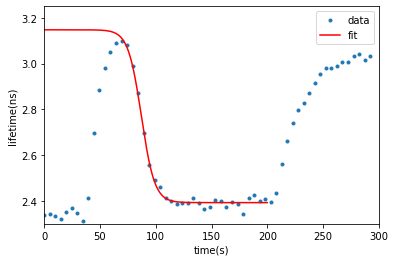

In [29]:
fig = plt.figure(1)
xax = np.arange(0,len(lifetimetrace)*frameinterval,frameinterval)
plt.plot(xax,lifetimetrace,'.',x,y,'r-')
plt.xlabel('time(s)')
plt.ylabel('lifetime(ns)')
plt.legend(['data','fit'])
plt.ylim([2.3,3.25])
plt.xlim([0,300])

In [30]:
fig.savefig(out_pth_ltf,dpi=600)